In [1]:
# Official packages
import os
import copy
import math
import re
import time

from pprint import pprint
from itertools import chain

# Third-party packages
import numpy as np
import scipy

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm


import pyopencl as cl
#for item in cl.get_platforms():
#    print(item.get_devices())

import pynufft
device_list = pynufft.helper.device_list()
for item in device_list:
    print(item)
    
# In-house packages
from BrukerPV360 import BrukerPV360Exp


def normalize_array(arr:np.array):
    return arr/np.max(np.abs(arr))

C:\Anaconda3\lib\site-packages\pytools\persistent_dict.py:59: UserWarning: pytools.persistent_dict: unable to import 'siphash24.siphash13', falling back to hashlib.sha256
  warn("pytools.persistent_dict: unable to import 'siphash24.siphash13', "


No cuda device found. Check your pycuda installation.
('ocl', 0, 0, <pyopencl.Platform 'Intel(R) OpenCL Graphics' at 0x286b6c20d70>, <pyopencl.Device 'Intel(R) UHD Graphics' on 'Intel(R) OpenCL Graphics' at 0x286bafc6a70>, <reikna.cluda.ocl.Thread object at 0x00000286BEA4A4F0>, 64)
('ocl', 1, 0, <pyopencl.Platform 'Intel(R) OpenCL' at 0x286bf35da60>, <pyopencl.Device '11th Gen Intel(R) Core(TM) i7-11850H @ 2.50GHz' on 'Intel(R) OpenCL' at 0x286bc7f9600>, <reikna.cluda.ocl.Thread object at 0x00000286BEA3E460>, 1)
('ocl', 2, 0, <pyopencl.Platform 'Intel(R) FPGA Emulation Platform for OpenCL(TM)' at 0x286bf35dcc0>, <pyopencl.Device 'Intel(R) FPGA Emulation Device' on 'Intel(R) FPGA Emulation Platform for OpenCL(TM)' at 0x286bc7f5f00>, <reikna.cluda.ocl.Thread object at 0x00000286BEA05400>, 64)


# Simple 2D spiral as introduction

We always start from the simplist case.

Load parameters and raw FID

1
1
[40. 40.]
[40. 40.]
[0.]
1425
[1. 1.]
(1425,)


<function matplotlib.pyplot.show(close=None, block=None)>

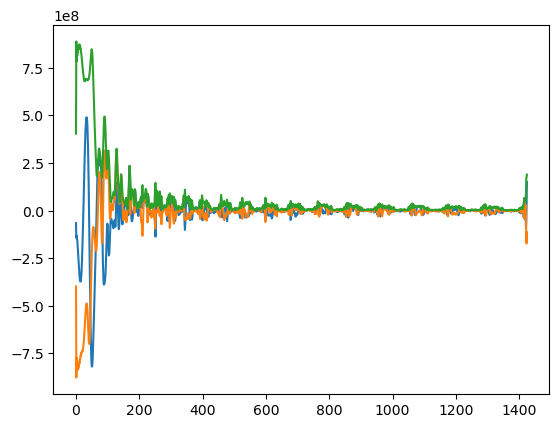

In [2]:
raw_path = "./TestData/BrukerPV360/Spiral2d1Intlv"

Spiral2d1Intlv = BrukerPV360Exp(raw_path, is_verbose=False)

FID = Spiral2d1Intlv.dataset['DATA']['rawdata'][0]


print((Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_NRepetitions']))
print((Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_SpiralNbOfInterleaves']))
print((Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_Matrix']))
print((Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_EncMatrix']))
print((Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_EncSteps2']))
print((Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_SpiralNbOfAcqPoints']))
print((Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_SpatResol']))
print(np.shape(FID))
plt.plot(np.real(FID))
plt.plot(np.imag(FID))
plt.plot(np.abs(FID))
plt.show

Now load waveform of readout gradient and then calculate trajactory in k-xy space.

It is worthy to note that the K-xy traj is not normalized. 

As a simple toy example, normalization-or-not is not crucial. We need to pay attention when the dimension becomes important when we are to do real-world cases.

(7126,)


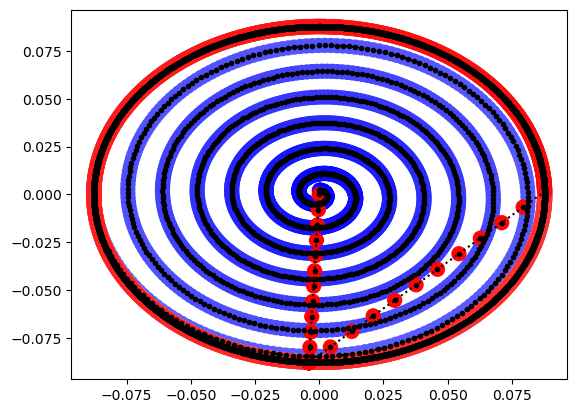

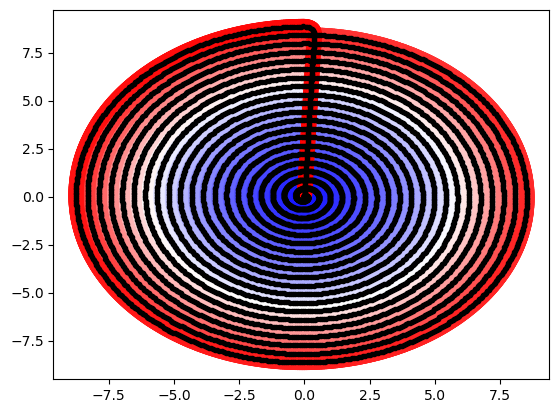

[-4.8701477e-06 -9.4501302e-05]


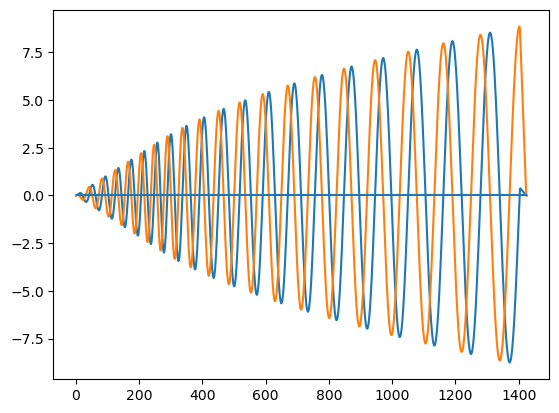

In [ ]:
spiral_y = (Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_SpiralShape1'])
spiral_x = (Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_SpiralShape2'])

print(np.shape(spiral_x))

plt.figure()
plt.scatter(spiral_x, spiral_y, c=(range(len(spiral_x))), s=100, cmap='bwr')
plt.plot(spiral_x, spiral_y, c= "black", marker='.', linestyle=':')
plt.show()

traj_cal_x = np.cumsum(spiral_x)
traj_cal_y = np.cumsum(spiral_y)

plt.figure()
plt.scatter(traj_cal_x, traj_cal_y, c=(range(len(traj_cal_y))), s=100, cmap='bwr')
plt.plot(traj_cal_x, traj_cal_y, c= "black", marker='.', linestyle=':')
plt.scatter(traj_cal_x, traj_cal_y, c=(range(len(traj_cal_y))), s=100, cmap='bwr')
plt.show()

spiral_traj_cal = np.asarray(list(zip(traj_cal_x,traj_cal_y)))[::5]

print(spiral_traj_cal[-1])
plt.plot(spiral_traj_cal)
plt.hlines(y=0,xmin=0,xmax=len(spiral_traj_cal))

Now we load Bruker factory recon result

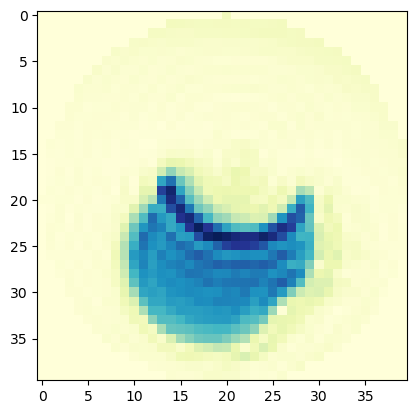

In [ ]:
bruker_data = Spiral2d1Intlv.dataset['DATA']['2dseq']

img_shape = [int(x) for x in Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_Matrix']]

NR = Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_NRepetitions']

bruker_data = np.reshape(bruker_data, img_shape)
plt.figure()
plt.imshow(bruker_data, cmap=cm.YlGnBu)
plt.show()


And here our PyNuFFT recon

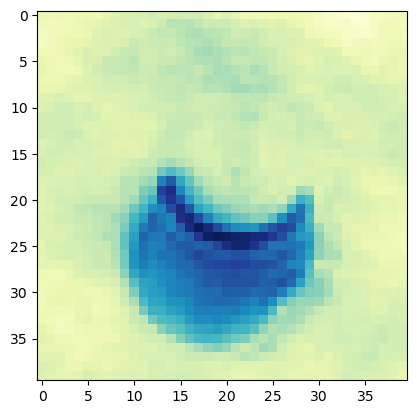

In [7]:
Nd = tuple(img_shape)  # image size
Kd = tuple([4*x for x in img_shape])  # k-space size
Jd = (6, 6)  # interpolation size

spiralObj = pynufft.NUFFT( )
spiralObj.plan(spiral_traj_cal, Nd, Kd, Jd)

bruker_data = np.reshape(bruker_data, img_shape)
y_cal = spiralObj.forward(bruker_data)
recon = spiralObj.solve(y_cal, solver='bicgstab', maxiter=500)
plt.figure()
plt.imshow(recon.real, cmap=cm.YlGnBu)
plt.show()


(1425,) (1426, 2)


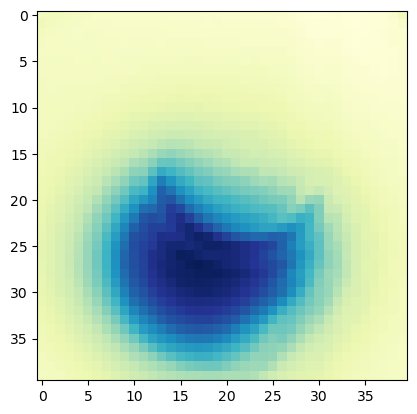

In [6]:
Nd = tuple(img_shape)  # image size
Kd = tuple([64*x for x in img_shape])  # k-space size
Jd = (6, 6)  # interpolation size


print(np.shape(FID), np.shape(spiral_traj_cal))
spiralObj = pynufft.NUFFT()
spiralObj.plan(spiral_traj_cal[1:]/np.pi, Nd, Kd, Jd)


recon = spiralObj.solve(np.roll(FID, 0), solver='bicgstab', maxiter=500)
plt.figure()
plt.imshow(np.abs(recon), cmap=cm.YlGnBu)
plt.show()


(1425,) (1426, 2)


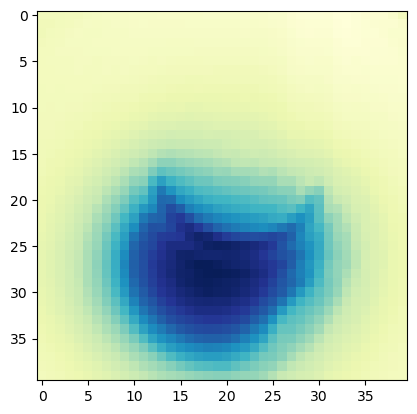

In [7]:
print(np.shape(FID), np.shape(spiral_traj_cal))
spiralObj = pynufft.NUFFT()
spiralObj.plan(spiral_traj_cal[:-1]/np.pi, Nd, Kd, Jd)


recon = spiralObj.solve(np.roll(FID, 0), solver='bicgstab', maxiter=500)
plt.figure()
plt.imshow(np.abs(recon), cmap=cm.YlGnBu)
plt.show()

(1425,) (1426, 2)


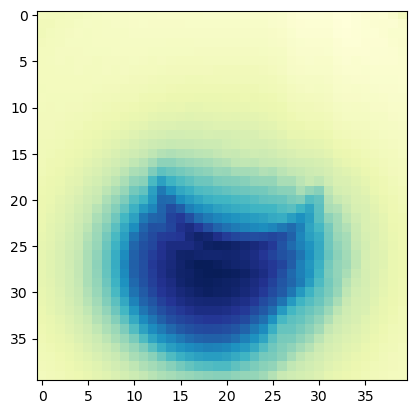

In [8]:
print(np.shape(FID), np.shape(spiral_traj_cal))
spiralObj = pynufft.NUFFT()
spiralObj.plan(spiral_traj_cal[1:]/np.pi, Nd, Kd, Jd)


recon = spiralObj.solve(np.roll(FID, -1), solver='bicgstab', maxiter=500)
plt.figure()
plt.imshow(np.abs(recon), cmap=cm.YlGnBu)
plt.show()

# Multi-Interleaved Sprial 2D

Here we advance a little to use 4 interleaves in the signal acquisition

1
4
[16. 16.]
[16. 16.]
[0.]
155
[3. 3.]
(620,)


<function matplotlib.pyplot.show(close=None, block=None)>

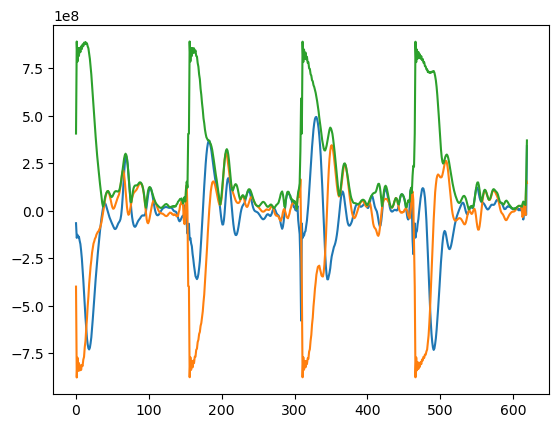

In [9]:
raw_path = "./TestData/BrukerPV360/Spiral2d4Intlv"

Spiral2d4Intlv = BrukerPV360Exp(raw_path, is_verbose=False)

FID = Spiral2d4Intlv.dataset['DATA']['rawdata'][0]


print((Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_NRepetitions']))
print((Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralNbOfInterleaves']))
print((Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_Matrix']))
print((Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_EncMatrix']))
print((Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_EncSteps2']))
print((Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralNbOfAcqPoints']))
print((Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_SpatResol']))
print(np.shape(FID))

plt.plot(np.real(FID))
plt.plot(np.imag(FID))
plt.plot(np.abs(FID))
plt.show

When composing the K-xy Traj, it is important to sequentialize all the 4 interleaves.

The color-map from blue to red suggests the order or 4 interleaves

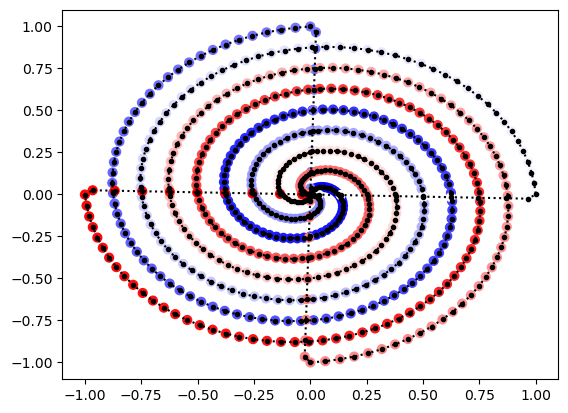

In [10]:
spiral_y = (Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralShape1'])
spiral_x = (Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralShape2'])

traj_cal_x = np.cumsum(spiral_x)[::5]
traj_cal_y = np.cumsum(spiral_y)[::5]

shift_cos = (Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralInterleavCos'])
shift_sin = (Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralInterleavSin'])
shift_angle = np.angle(shift_cos+1j*shift_sin)

traj_cal_seg = traj_cal_x + 1j*traj_cal_y
traj_cal = []
for angle in shift_angle:
    traj_cal.append(traj_cal_seg[:155] * np.exp(-angle*1j))

traj_cal = np.asarray(traj_cal).flatten()
traj_Kxy = normalize_array(traj_cal)

plt.figure()
plt.plot(traj_Kxy.real, traj_Kxy.imag, c= "black", marker='.', linestyle=':')
plt.scatter(traj_Kxy.real, traj_Kxy.imag, c=(range(len(traj_cal))), s=40, cmap='bwr')
plt.show()



as before, we load Bruker recon

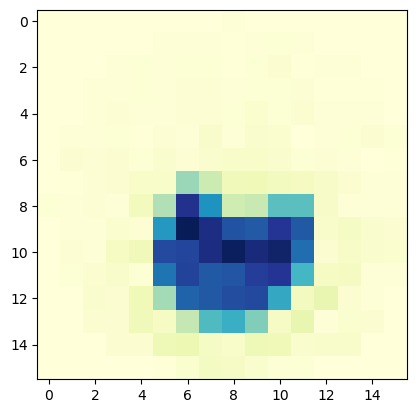

In [11]:
bruker_data = Spiral2d4Intlv.dataset['DATA']['2dseq']

img_shape = [int(x) for x in Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_Matrix']]

NR = Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_NRepetitions']

bruker_data = np.reshape(bruker_data, img_shape)
plt.figure()
plt.imshow(bruker_data, cmap=cm.YlGnBu)
plt.show()

(620,) (1426, 2)


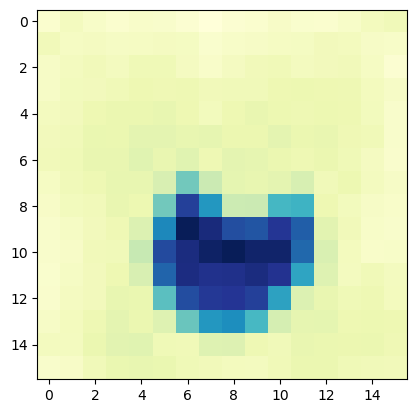

In [12]:
Nd = tuple(img_shape)  # image size
Kd = tuple([8*x for x in img_shape])  # k-space size
Jd = (6, 6)  # interpolation size

spiral_traj = np.asarray([[Kxy.real, Kxy.imag] for Kxy in traj_Kxy ])

print(np.shape(FID), np.shape(spiral_traj_cal))
spiralObj = pynufft.NUFFT()
spiralObj.plan(spiral_traj*np.pi, Nd, Kd, Jd)


recon = spiralObj.solve(np.roll(FID, 0), solver='bicgstab', maxiter=500)
plt.figure()
plt.imshow(np.abs(recon), cmap=cm.YlGnBu)
plt.show()

# Now we enter 3D realm

The composition of k-space include two steps:

k-xy spirals as in previous section

k-z stack is obtained directly from \<Method\> file

and they got combined

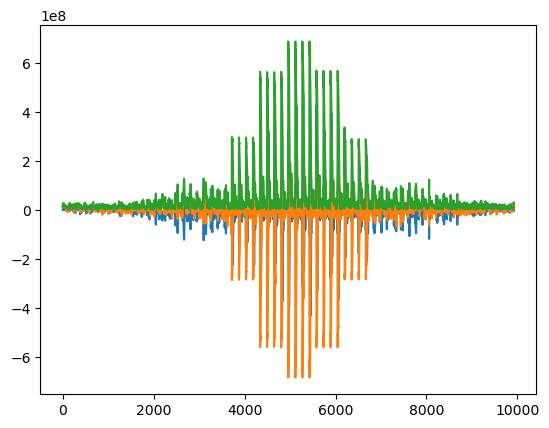

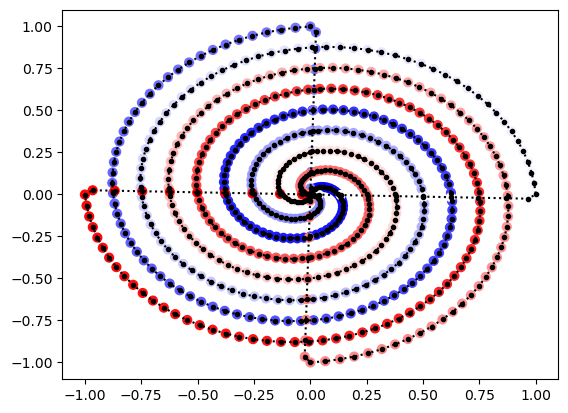

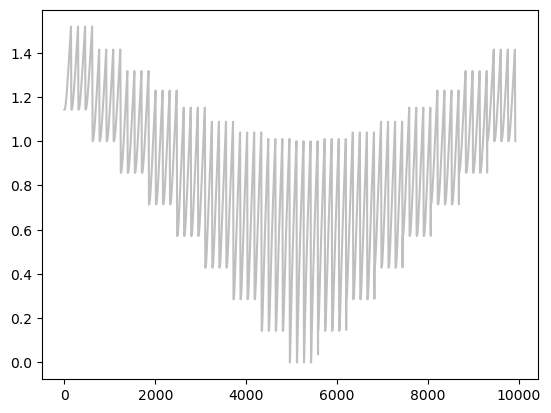

In [13]:
raw_path = "./TestData/BrukerPV360/Spiral3d4Intlv"

Spiral3d4Intlv = BrukerPV360Exp(raw_path, is_verbose=False)

FID = Spiral3d4Intlv.dataset['DATA']['rawdata'][0]

plt.plot(np.real(FID))
plt.plot(np.imag(FID))
plt.plot(np.abs(FID))
plt.show

spiral_y = (Spiral3d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralShape1'])
spiral_x = (Spiral3d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralShape2'])

traj_cal_x = np.cumsum(spiral_x)[::5]
traj_cal_y = np.cumsum(spiral_y)[::5]

shift_cos = (Spiral3d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralInterleavCos'])
shift_sin = (Spiral3d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralInterleavSin'])
shift_angle = np.angle(shift_cos+1j*shift_sin)

traj_cal_seg = traj_cal_x + 1j*traj_cal_y
traj_cal = []
for angle in shift_angle:
    traj_cal.append(traj_cal_seg[:155] * np.exp( -angle*1j))

traj_cal = np.asarray(traj_cal).flatten()
traj_Kxy = traj_cal / np.max(np.abs(traj_cal))

plt.figure()
plt.plot(traj_Kxy.real, traj_Kxy.imag, c= "black", marker='.', linestyle=':')
plt.scatter(traj_Kxy.real, traj_Kxy.imag, c=(range(len(traj_cal))), s=40, cmap='bwr')
plt.show()

traj_Kz = Spiral3d4Intlv.dataset['PARAM']['method'][0]['PVM_EncSteps2']
traj_Kz = traj_Kz / np.max(traj_Kz)

traj_K3d = []
for kz in traj_Kz:
    for kxy in traj_Kxy:
        traj_K3d.append([kxy.real, kxy.imag, kz])
traj_K3d = np.asarray(traj_K3d)

traj_K3d_norm = np.linalg.norm(traj_K3d, ord=2, axis=1)
plt.figure()
plt.plot(traj_K3d_norm, c= "black", marker=' ',alpha=.25)
plt.show()

Here below we visualize the 3d k-space sampling mesh

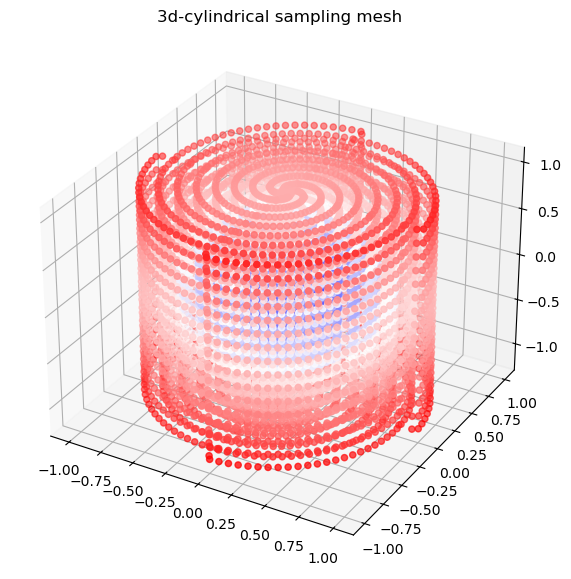

In [14]:
fig = plt.figure(figsize = (10, 7))
ax = plt.axes(projection ="3d")

ax.scatter3D(traj_K3d[:,0], traj_K3d[:,1], traj_K3d[:,2], c = traj_K3d_norm, cmap='bwr')
plt.title("3d-cylindrical sampling mesh")
 
# show plot
plt.show()

Bruker Recon

[16, 16, 16]


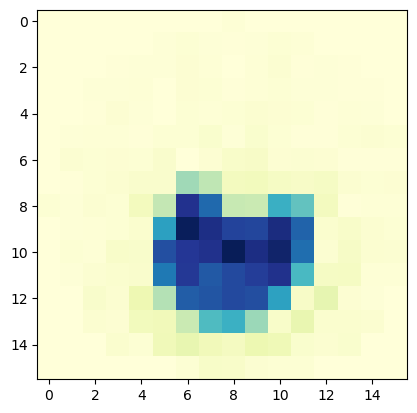

In [15]:
bruker_data = Spiral3d4Intlv.dataset['DATA']['2dseq']

img_shape = [int(x) for x in Spiral3d4Intlv.dataset['PARAM']['method'][0]['PVM_Matrix']]
print(img_shape)
NR = Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_NRepetitions']

bruker_data = np.reshape(bruker_data, img_shape)
plt.figure()
plt.imshow(bruker_data[8], cmap=cm.YlGnBu)
plt.show()

Our 3d-NuFFT recon

In [17]:
Nd = tuple(img_shape)  # image size
Kd = tuple([8*x for x in img_shape])  # k-space size
Jd = (6, 6, 6)  # interpolation size

print(np.shape(FID), np.shape(traj_Kxy), np.shape(traj_K3d))
print(Nd, Kd, Jd)

spiralStackObj = pynufft.NUFFT()
#spiralStackObj = pynufft.NUFFT(pynufft.helper.device_list()[0])
spiralStackObj.plan(traj_K3d*np.pi, Nd, Kd, Jd)

time1 = time.time()
recon = spiralStackObj.solve(FID, solver='cg', maxiter=500)
time2 = time.time()
print(time2-time1)

# 59.8 sec on Dell laptop with 100% CPU occupation.



(9920,) (620,) (9920, 3)
(16, 16, 16) (128, 128, 128) (6, 6, 6)
59.87181568145752


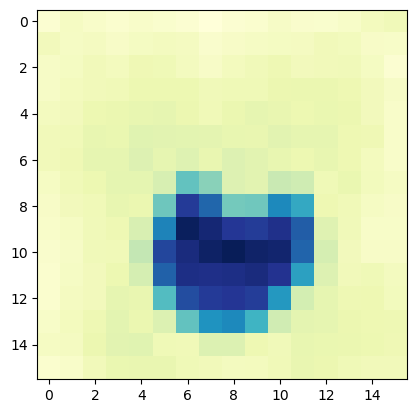

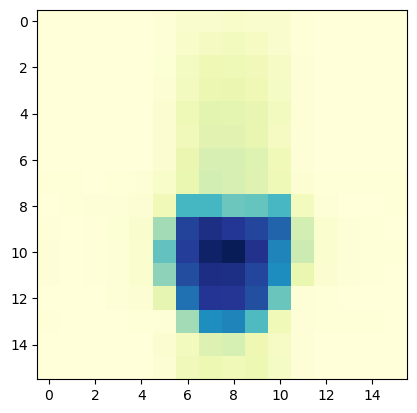

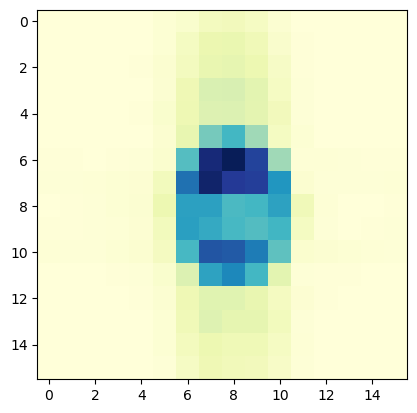

In [18]:
plt.figure()
plt.imshow(np.abs(recon)[:,:,8], cmap=cm.YlGnBu)
plt.show()
plt.figure()
plt.imshow(np.abs(recon)[:,8,:], cmap=cm.YlGnBu)
plt.show()
plt.figure()
plt.imshow(np.abs(recon)[8,:,:], cmap=cm.YlGnBu)
plt.show()

A 3d representation of the NuFFT recon

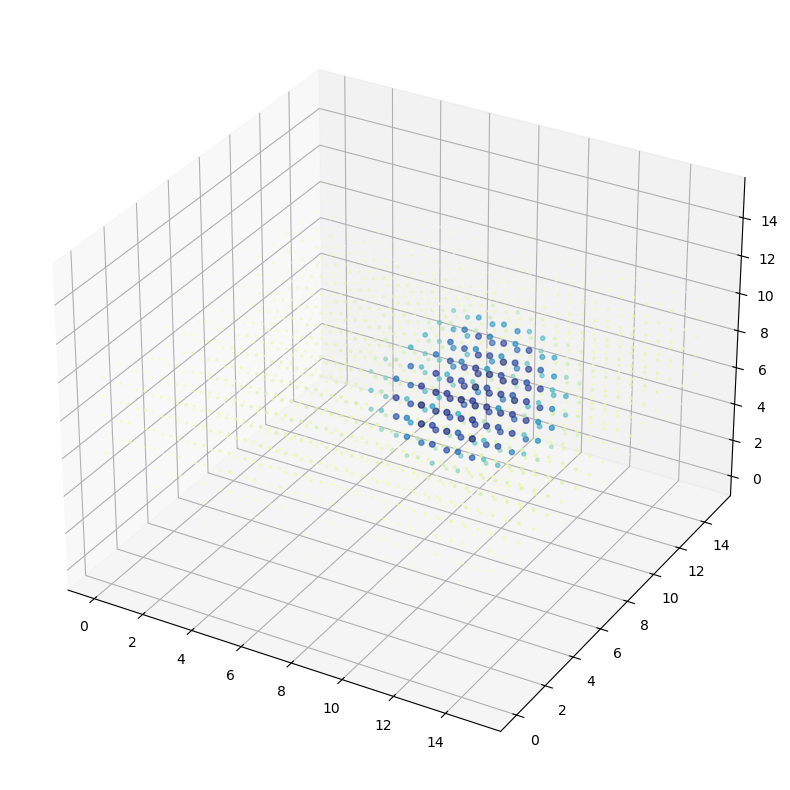

In [19]:
from itertools import product
from matplotlib import pyplot as plt
N = 16
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection="3d")
space = np.array([*product(range(N), range(N), range(N))]) # all possible triplets of numbers from 0 to N-1
volume = normalize_array(np.abs(recon))
ax.scatter(space[:,0], space[:,1], space[:,2], c=volume, s=volume*20, cmap='YlGnBu')

# hpSpiral3d Recon

We first build the k-mesh as in the previous section

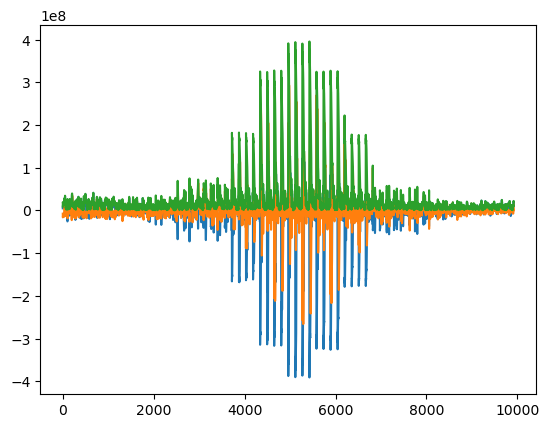

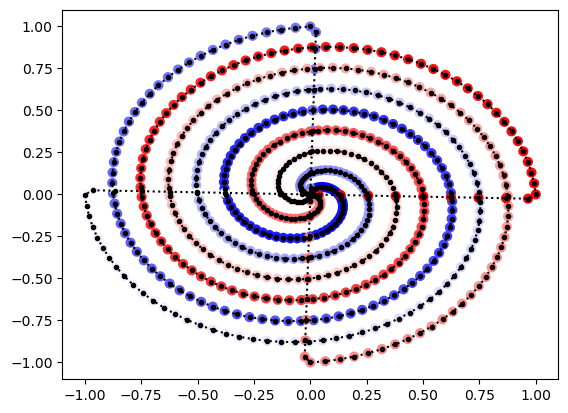

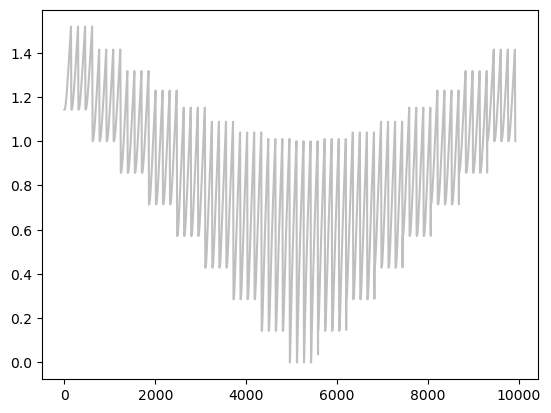

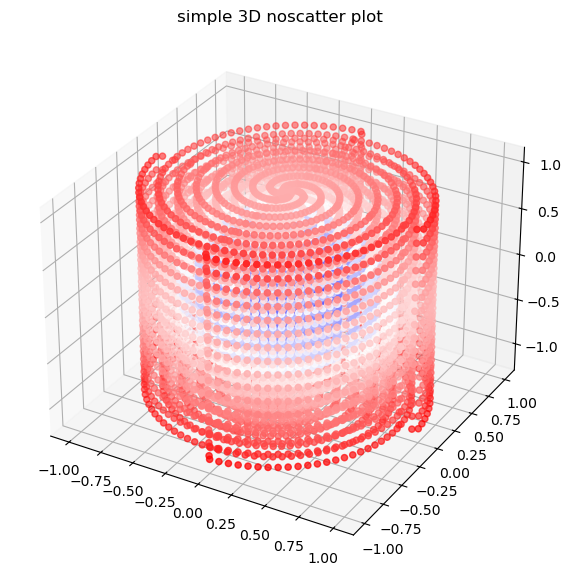

In [8]:
raw_path = "./TestData/BrukerPV360/hpSpiral3d"

hpSpiral3d = BrukerPV360Exp(raw_path, is_verbose=False)

FID = hpSpiral3d.dataset['DATA']['rawdata'][0]

plt.plot(np.real(FID))
plt.plot(np.imag(FID))
plt.plot(np.abs(FID))
plt.show

spiral_y = (hpSpiral3d.dataset['PARAM']['method'][0]['PVM_SpiralShape1'])
spiral_x = (hpSpiral3d.dataset['PARAM']['method'][0]['PVM_SpiralShape2'])

traj_cal_x = np.cumsum(spiral_x)[::5]
traj_cal_y = np.cumsum(spiral_y)[::5]

shift_cos = (hpSpiral3d.dataset['PARAM']['method'][0]['PVM_SpiralInterleavCos'])
shift_sin = (hpSpiral3d.dataset['PARAM']['method'][0]['PVM_SpiralInterleavSin'])
shift_angle = np.angle(shift_cos+1j*shift_sin)

traj_cal_seg = traj_cal_x + 1j*traj_cal_y
traj_cal = []
for angle in shift_angle:
    traj_cal.append(traj_cal_seg[:155] * np.exp( angle*1j))

traj_cal = np.asarray(traj_cal).flatten()
traj_Kxy = traj_cal / np.max(np.abs(traj_cal))

plt.figure()
plt.plot(traj_Kxy.real, traj_Kxy.imag, c= "black", marker='.', linestyle=':')
plt.scatter(traj_Kxy.real, traj_Kxy.imag, c=(range(len(traj_cal))), s=40, cmap='bwr')
plt.show()

traj_Kz = hpSpiral3d.dataset['PARAM']['method'][0]['PVM_EncSteps2']
traj_Kz = traj_Kz / np.max(traj_Kz)

traj_K3d = []
for kz in traj_Kz:
    for kxy in traj_Kxy:
        traj_K3d.append([kxy.real, kxy.imag, kz])
traj_K3d = np.asarray(traj_K3d)

traj_K3d_norm = np.linalg.norm(traj_K3d, ord=2, axis=1)
plt.figure()
plt.plot(traj_K3d_norm, c= "black", marker=' ',alpha=.25)
plt.show()

fig = plt.figure(figsize = (10, 7))
ax = plt.axes(projection ="3d")
ax.scatter3D(traj_K3d[:,0], traj_K3d[:,1], traj_K3d[:,2], c = traj_K3d_norm, cmap='bwr')
plt.title("simple 3D noscatter plot") 
# show plot
plt.show()

The stupid Bruker recon has bug

[16, 16, 16]


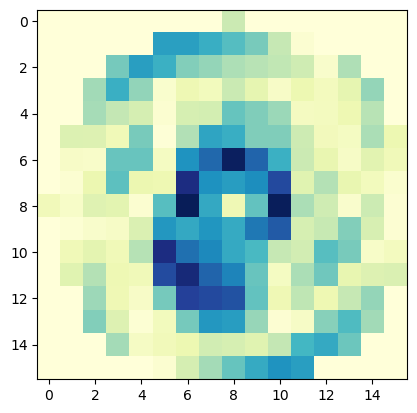

In [10]:
bruker_data = hpSpiral3d.dataset['DATA']['2dseq']

img_shape = [int(x) for x in hpSpiral3d.dataset['PARAM']['method'][0]['PVM_Matrix']]
print(img_shape)
NR = Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_NRepetitions']

bruker_data = np.reshape(bruker_data, img_shape)
plt.figure()
plt.imshow(bruker_data[8], cmap=cm.YlGnBu)
plt.show()

Our 3d NuFFT recon with 4090 Video card is pretty fast

In [11]:
Nd = tuple(img_shape)  # image size
Kd = tuple([8*x for x in img_shape])  # k-space size
Jd = (6, 6, 6)  # interpolation size

print(np.shape(FID), np.shape(traj_Kxy), np.shape(traj_K3d))
print(Nd, Kd, Jd)

# this line takes the CPU approach, which is at least 4 times slower with all 16 cores 100% occupied
spiralStackObj = pynufft.NUFFT() 
# this line takes the GPU approach, which requires the pycuda package finds a GPU
#spiralStackObj = pynufft.NUFFT(pynufft.helper.device_list()[0])
spiralStackObj.plan(traj_K3d*np.pi, Nd, Kd, Jd)

time1 = time.time()
recon = spiralStackObj.solve(FID, solver='cg', maxiter=500)
time2 = time.time()
print(time2-time1)



(9920,) (620,) (9920, 3)
(16, 16, 16) (128, 128, 128) (6, 6, 6)
52.71425819396973


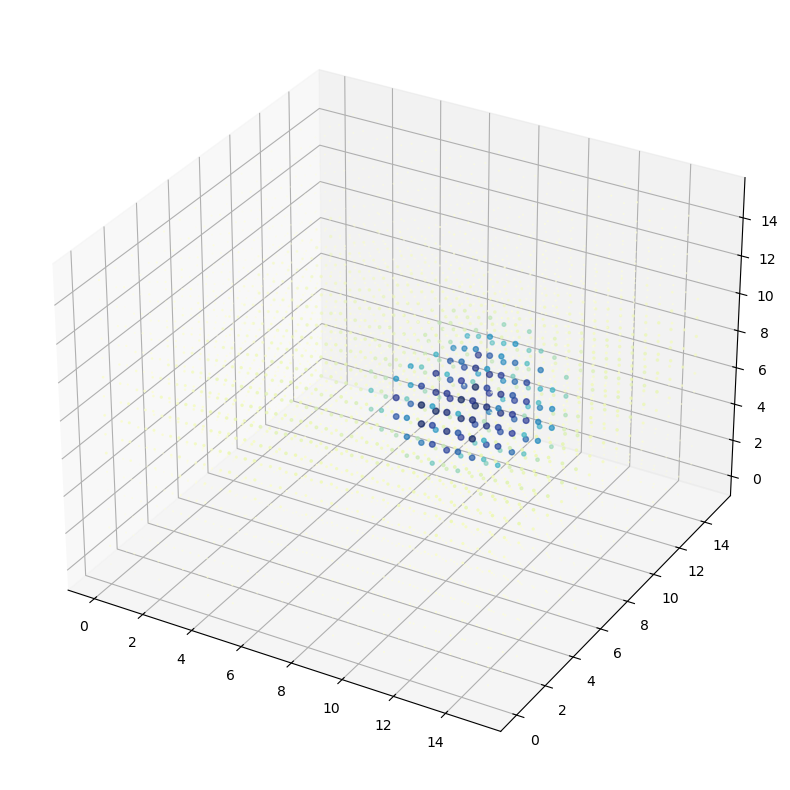

In [12]:
from itertools import product
from matplotlib import pyplot as plt
N = 16
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection="3d")
space = np.array([*product(range(N), range(N), range(N))]) # all possible triplets of numbers from 0 to N-1
volume = normalize_array(np.abs(recon))
ax.scatter(space[:,0], space[:,1], space[:,2], c=volume, s=volume*20, cmap='YlGnBu')

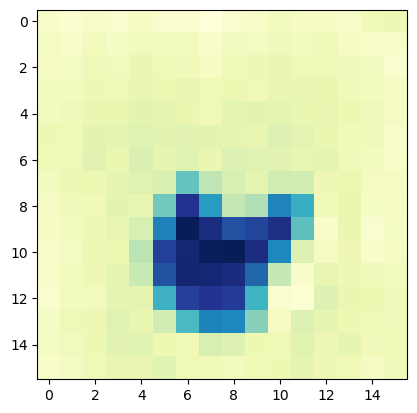

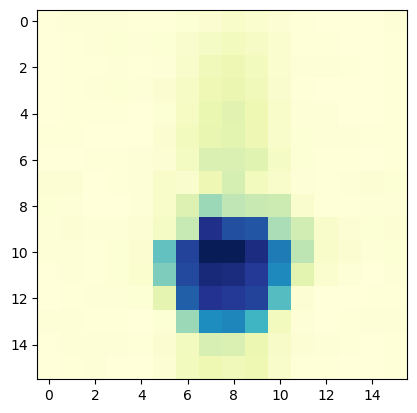

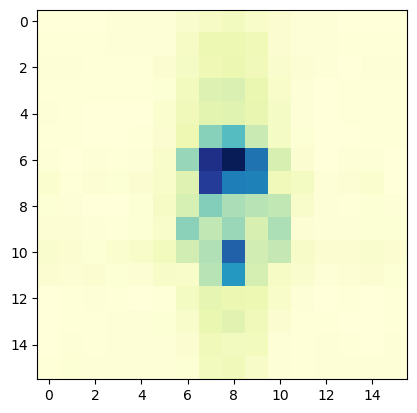

In [13]:
plt.figure()
plt.imshow(np.abs(recon)[:,:,8], cmap=cm.YlGnBu)
plt.show()
plt.figure()
plt.imshow(np.abs(recon)[:,8,:], cmap=cm.YlGnBu)
plt.show()
plt.figure()
plt.imshow(np.abs(recon)[8,:,:], cmap=cm.YlGnBu)
plt.show()

And the NuFFT result seems resonable.